# Task 1: Data preparation and customer analytics

# Quantium Chips Case Study 🛒

**Objective:**  
Understand customer purchasing behavior in the Chips category to provide data-driven recommendations for the upcoming category review.  

We will:
- Clean and prepare the data
- Analyze customer segments
- Visualize trends
- Provide strategic business recommendations

**Tools Used:** Python, Pandas, Matplotlib, Seaborn

## Import Required Libraries
We'll use popular Python libraries for data analysis and visualization.

In [1]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for visualizations
import seaborn as sns # for advanced visualizations

sns.set(style="whitegrid") # set a clean seaborn style for plots

## Load the Data
We load transaction data (purchases) and customer data (profiles).

In [4]:
# Load the datasets
transactions=pd.read_csv(r"C:\Users\Hp\Downloads\QVI_transaction_data (1).csv")
customers=pd.read_csv(r"C:\Users\Hp\Downloads\QVI_purchase_behaviour (1).csv")

#View a few rows to understand structure
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


## Inspect Column Names
Let’s check the columns to understand the structure of both datasets.

In [10]:
print("Transaction Columns:",transactions.columns)
print("Customer Columns:",customers.columns)

Transaction Columns: Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')
Customer Columns: Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='object')


## Data Quality Check
Check for missing values and understand column data types.

In [5]:
# Check for missing values
print("Transactions nulls:\n", transactions.isnull().sum())
print("\nCustomers nulls:\n", customers.isnull().sum())

#Understand the data types
transactions.info()

Transactions nulls:
 DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

Customers nulls:
 LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


## Step 4: Filter for Chips Only
We only want to analyze chip purchases, so we filter by product category.

In [11]:
# Filter only rows where the product name contains 'Chips'
chips = transactions[transactions['PROD_NAME'].str.contains("Chips",case=False,na=False)]

# Display first few rows
chips.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
10,43602,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
14,43600,19,19272,16686,44,Thins Chips Light& Tangy 175g,1,3.3
33,43603,45,45220,41651,22,Thins Chips Originl saltd 175g,1,3.3


## Feature Engineering
We'll create two new columns:
- `PACK_SIZE`: Extracted from the product name (e.g., 175g)
- `BRAND`: First word of the product name

In [13]:
chips['PACK_SIZE']=chips['PROD_NAME'].str.extract(r'(\d+)[gG]').astype(float)
chips['BRAND']=chips['PROD_NAME'].str.split().str[0]
chips[['PROD_NAME','PACK_SIZE','BRAND']].head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17244\2594707255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chips['PACK_SIZE']=chips['PROD_NAME'].str.extract(r'(\d+)[gG]').astype(float)
C:\Users\Hp\AppData\Local\Temp\ipykernel_17244\2594707255.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chips['BRAND']=chips['PROD_NAME'].str.split().str[0]


,PROD_NAME,PACK_SIZE,BRAND
2,Smiths Crinkle Cut Chips Chicken 170g,170.0,Smiths
6,Smiths Crinkle Chips Salt & Vinegar 330g,330.0,Smiths
10,Smiths Crinkle Chips Salt & Vinegar 330g,330.0,Smiths
14,Thins Chips Light& Tangy 175g,175.0,Thins
33,Thins Chips Originl saltd 175g,175.0,Thins


## Remove Outliers
To reduce noise in the data, we’ll remove the top 1% of sales values (likely due to error or bulk buys).

In [15]:
chips=chips[chips['TOT_SALES']<chips['TOT_SALES'].quantile(0.99)]

## Merge Chips Data with Customer Segments
We merge with the customer dataset on `LYLTY_CARD_NBR` to include segmentation info (LIFESTAGE, PREMIUM_CUSTOMER).

In [17]:
chips_merged=pd.merge(chips,customers,on='LYLTY_CARD_NBR',how='inner')
chips_merged.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
1,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
2,43602,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,43600,19,19272,16686,44,Thins Chips Light& Tangy 175g,1,3.3,175.0,Thins,MIDAGE SINGLES/COUPLES,Budget
4,43603,45,45220,41651,22,Thins Chips Originl saltd 175g,1,3.3,175.0,Thins,MIDAGE SINGLES/COUPLES,Budget


## Customer Segment Analysis
We’ll group data by `LIFESTAGE` and `PREMIUM_CUSTOMER` to calculate:
- Total sales
- Unique customers
- Transactions
- Avg. quantity per transaction
- Avg. spend per transaction

In [18]:
segment_summary=chips_merged.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg(
    total_sales=('TOT_SALES','sum'),
    num_customers=('LYLTY_CARD_NBR','nunique'),
    num_transactions=('TXN_ID','nunique'),
    avg_units_per_txn=('PROD_QTY','mean'),
    avg_sales_per_txn=('TOT_SALES','mean')
).reset_index()

segment_summary

,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,num_customers,num_transactions,avg_units_per_txn,avg_sales_per_txn
0,MIDAGE SINGLES/COUPLES,Budget,4375.0,578,765,1.845752,5.718954
1,MIDAGE SINGLES/COUPLES,Mainstream,10041.9,1278,1657,1.865419,6.060290
2,MIDAGE SINGLES/COUPLES,Premium,6835.6,899,1191,1.837385,5.729757
3,NEW FAMILIES,Budget,2613.5,356,441,1.823129,5.926304
4,NEW FAMILIES,Mainstream,1865.9,270,319,1.799373,5.849216
5,NEW FAMILIES,Premium,1327.1,190,230,1.808696,5.770000
6,OLDER FAMILIES,Budget,19788.4,2234,3328,1.917492,5.937114
7,OLDER FAMILIES,Mainstream,12368.0,1370,2075,1.912458,5.949014
8,OLDER FAMILIES,Premium,9518.4,1097,1618,1.924645,5.879185
9,OLDER SINGLES/COUPLES,Budget,15680.1,2001,2637,1.865530,5.939432


## Visualize Segment-Wise Sales
Let’s visualize total chip sales by customer segments using a bar chart.

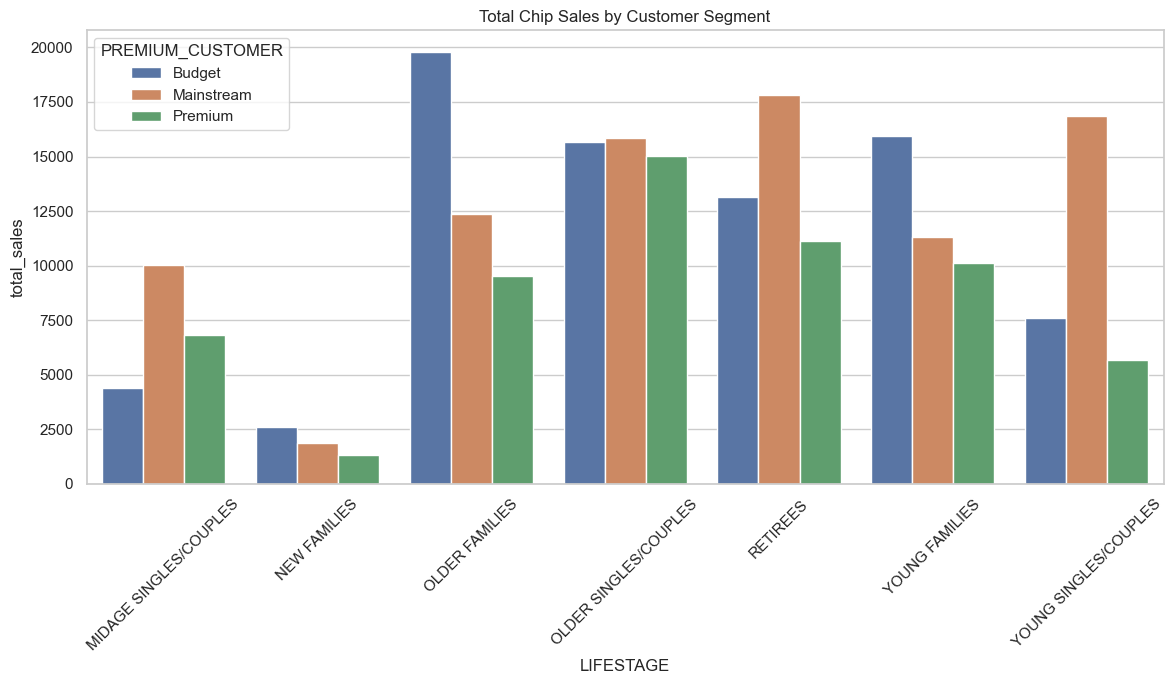

In [23]:
plt.figure(figsize=(12,7))
sns.barplot(data=segment_summary,x='LIFESTAGE',y='total_sales',hue='PREMIUM_CUSTOMER')
plt.title('Total Chip Sales by Customer Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Total Sales by Brand

C:\Users\Hp\AppData\Local\Temp\ipykernel_17244\2439972805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_sales, x='BRAND', y='TOT_SALES', palette='viridis')


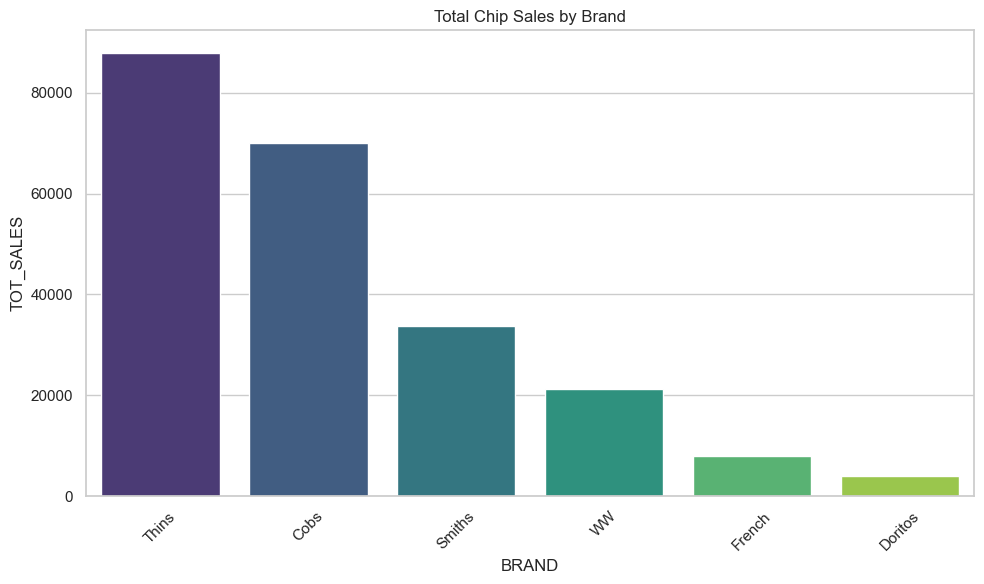

In [25]:
brand_sales = chips_merged.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=brand_sales, x='BRAND', y='TOT_SALES', palette='viridis')
plt.title('Total Chip Sales by Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Sales by Pack Size

C:\Users\Hp\AppData\Local\Temp\ipykernel_17244\1070909485.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pack_sales, x='PACK_SIZE', y='TOT_SALES', palette='magma')


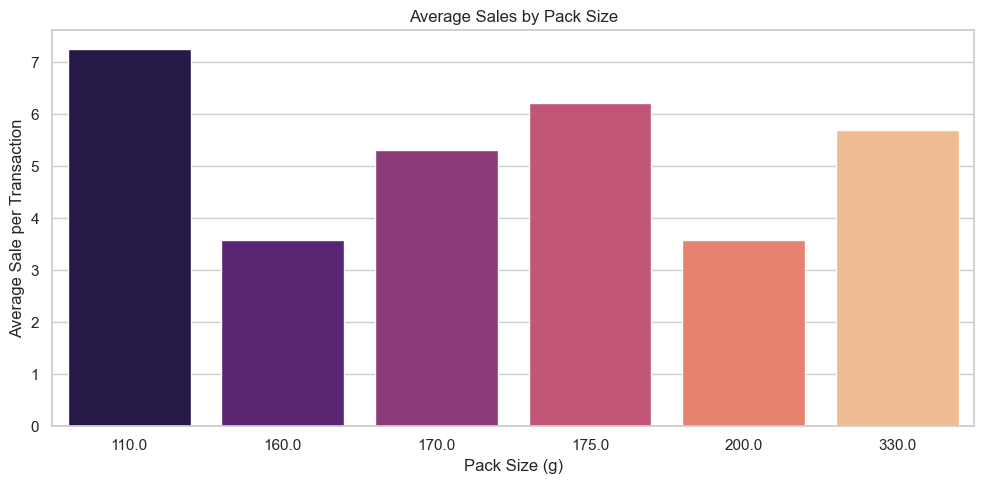

In [26]:
pack_sales = chips_merged.groupby('PACK_SIZE')['TOT_SALES'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=pack_sales, x='PACK_SIZE', y='TOT_SALES', palette='magma')
plt.title('Average Sales by Pack Size')
plt.xlabel('Pack Size (g)')
plt.ylabel('Average Sale per Transaction')
plt.tight_layout()
plt.show()

## Sales Over Time

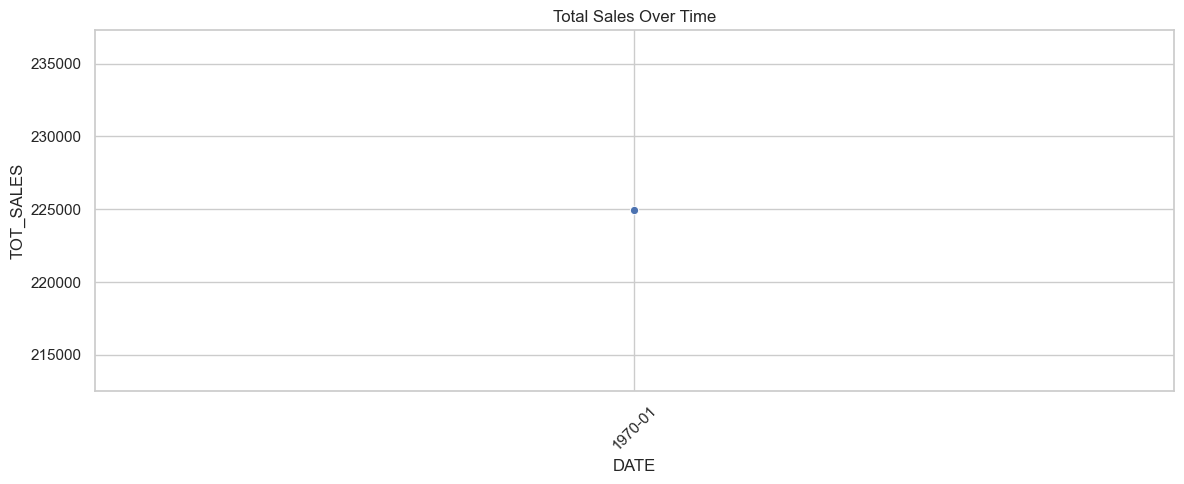

In [29]:
chips_merged['DATE'] = pd.to_datetime(chips_merged['DATE'])

# Group by month
monthly_sales = chips_merged.groupby(chips_merged['DATE'].dt.to_period('M'))['TOT_SALES'].sum().reset_index()
monthly_sales['DATE'] = monthly_sales['DATE'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='DATE', y='TOT_SALES', marker='o')
plt.title('Total Sales Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Cleaned and Summary Files
Save cleaned and summarized data to CSV for reporting or exporting as PDF.

In [30]:
chips_merged.to_csv('chips_cleaned.csv', index=False)
segment_summary.to_csv('segment_summary.csv', index=False)

## 🧠 Business Recommendations

Based on the chip sales data, here are key recommendations for the Category Manager:

1. **Focus on Mainstream and Young Singles/Couples**
   - These customers have **high sales volume**.
   - They show strong buying behavior even without premium membership.
   - 🎯 **Action**: Create promotions targeting this group through online platforms or student deals.

2. **Premium Families Spend More Per Transaction**
   - Their **average spend per transaction is higher** than other segments.
   - 🎯 **Action**: Upsell them larger pack sizes or premium brands with family deals.

3. **Opportunity to Grow Older or Budget Segments**
   - Retirees and budget-conscious customers buy less.
   - 🎯 **Action**: Run sampling or discount campaigns to test response.

4. **Top Brands Like Smiths Dominate**
   - Smiths and Thins are frequently purchased.
   - 🎯 **Action**: Ensure consistent supply of bestsellers in stores.

5. **Pack Sizes around 175g-200g are Popular**
   - Most customers choose mid-size packs.
   - 🎯 **Action**: Optimize pack size variety and offer bundle deals.

## 📌 Summary

Focus marketing on high-value segments, tailor offers to drive repeat purchases, and use insights to inform product mix and shelf planning.
